### Imports

In [4]:
import subprocess
import os
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader


from models.archs.ConvNet import ConvNet
from config import parameters
from unlearn.GA import GA
from data.utils import get_unlearn_loader, setup_model_dataset, accuracy
from trainer.utils import get_memory_footprint, get_model_weight_norm, check_accuracy
parameters["seed"] = 42

### Further split retain set into train and val

### Data loaders

Dataset information: CIFAR-10	 45000 images for training 	 5000 images for validation	
10000 images for testing	 no normalize applied in data_transform
Training data augmentation = randomcrop(32,4) + randomhorizontalflip
Dataset information: CIFAR-10	 45000 images for training 	 5000 images for validation	
10000 images for testing	 no normalize applied in data_transform
Training data augmentation = randomcrop(32,4) + randomhorizontalflip


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.7537313].


datasets length:  4500 40500
SPLITTING RETAIN SET INTO TRAIN AND VAL:

Dataset information: CIFAR-10	 36450 images for training 	 4050 images for validation	


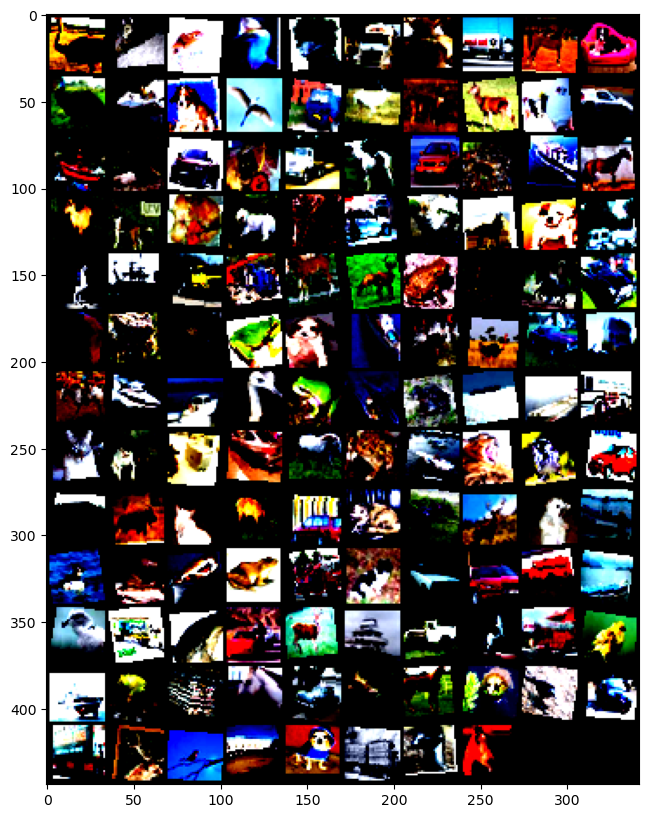

In [ ]:
from torchvision.utils import make_grid
# # ... define a dataset, forget set, and retain set
_, _, _, marked_loader = setup_model_dataset(args = parameters)
forget_loader, retain_loader = get_unlearn_loader(marked_loader = marked_loader, args = parameters)
train_loader, val_loader, test_loader = retain_to_train_and_val(retain_loader = retain_loader, num_workers = 0, seed = parameters["seed"], shuffle = True)

X, y = next(iter(train_loader))
plt.figure(figsize=(18,10))
plt.imshow(make_grid(X, nrow=10).permute((1,2,0)));

### Run it

In [5]:
import random

def group_runs(seed = 42, num_runs_each = 2, num_epochs = 20, measure_every = 2, main_folder = "results"):

    # apply seed to params, so all downstream functions can use it
    parameters["seed"] = seed

    # Make folder if it doesnt already exist
    if not os.path.exists(main_folder):
        print(f"{main_folder} doesn't exist - creating it...")
        os.makedirs(main_folder, exist_ok=True)

    # Save the config for this run to the main folder
    ULR = 3e-6 # this is a good one for the full regime
    # ULR = 5e-6 # this is a good one for a quick test run
    run_config = {
        "num_runs_each": num_runs_each,
        "num_epochs": num_epochs,
        "measure_every": measure_every,
        "ULR": ULR
    }
    with open(os.path.join(main_folder, "config.json"), "w") as f:
        json.dump(run_config, f, indent=4)

    # For each class ...
    for c in range(0, 10):

        print("="*50 + "    " + f"CLASS {c}\n")

        #... assign it as class to forget
        parameters["class_to_replace"] = c
        print(f"Class to forget for this run: {c}\n")

        # ... and do some number of runs, where
        for i in range(1, num_runs_each+1):

            print("-"*25 + "    " + f"RUN {i}\n")
            run_name = f"class_{c}_run_{i}"

            # ... load a model checkpoint from which to begin unlearning
            device = torch.device("mps") if torch.mps.is_available() else torch.device("cpu")
            base_model = ConvNet()
            checkpoint = torch.load("models/model_checkpoints/ConvNet_CIFAR10_2026-03-17.pth")
            base_model.load_state_dict(checkpoint["model_state_dict"])
            base_model.to(device)
        
            # ... define data loaders w.r.t. class to forget
            # ----- we are deliberately defining these inside the loop, so that they are refreshed for each run, hence more random
            train_full_loader, val_loader, test_loader, marked_loader = setup_model_dataset(args = parameters)
            forget_loader, retain_loader = get_unlearn_loader(marked_loader = marked_loader, args = parameters)
            
            # ... define params
            opt = optim.Adam(base_model.parameters(), lr=ULR)
            criterion = nn.CrossEntropyLoss()

            # ... and run the unlearning regimen
            _ = unlearn_regimen(base_model, forget_loader, retain_loader, num_epochs, criterion, opt, print_freq = 15, measure_every = measure_every, device = device, name = run_name, save_folder = main_folder)

In [ ]:
# MAKE A RANDOM SEED
seed = 22
# DO EXP
group_runs(seed = seed, num_runs_each = 10, num_epochs = 12, measure_every=1, main_folder = f"results/seed_{seed}")

results/seed_22 doesn't exist - creating it...
==================================================    CLASS 0

Class to forget for this run: 0

-------------------------    RUN 1

Dataset information: CIFAR-10	 45000 images for training 	 5000 images for validation	
10000 images for testing	 no normalize applied in data_transform
Training data augmentation = randomcrop(32,4) + randomhorizontalflip
Dataset information: CIFAR-10	 45000 images for training 	 5000 images for validation	
10000 images for testing	 no normalize applied in data_transform
Training data augmentation = randomcrop(32,4) + randomhorizontalflip
datasets length:  4500 40500


/opt/miniconda3/envs/comp0081/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Baseline | Forget Set Accuracy: 0.92 | Retain Set Accuracy: 0.93
Epoch: [1][0/36]	Loss -0.2906 (-0.2906)	Accuracy 89.844 (89.844)	Time 0.36
Epoch: [1][15/36]	Loss -0.2701 (-0.2765)	Accuracy 92.969 (91.455)	Time 1.14
Epoch: [1][30/36]	Loss -0.4413 (-0.2834)	Accuracy 85.156 (91.003)	Time 1.10
Epoch: 1 | Forget Set Accuracy: 0.882 | Retain Set Accuracy: 0.927 | Test Set Accuracy: 0.866

results/seed_22/epoch_1 doesn't exist - creating it...
Epoch: [2][0/36]	Loss -0.2845 (-0.2845)	Accuracy 88.281 (88.281)	Time 0.34
Epoch: [2][15/36]	Loss -0.4360 (-0.3822)	Accuracy 85.938 (86.914)	Time 1.16
Epoch: [2][30/36]	Loss -0.5745 (-0.4282)	Accuracy 84.375 (85.307)	Time 1.10
Epoch: 2 | Forget Set Accuracy: 0.822 | Retain Set Accuracy: 0.926 | Test Set Accuracy: 0.867

results/seed_22/epoch_2 doesn't exist - creating it...


/var/folders/tv/n3k6_fsd1399026cv2pr0n1r0000gn/T/ipykernel_59635/1862003329.py:32: UserWarning: The palette list has more values (20) than needed (3), which may not be intended.
  sns.scatterplot(


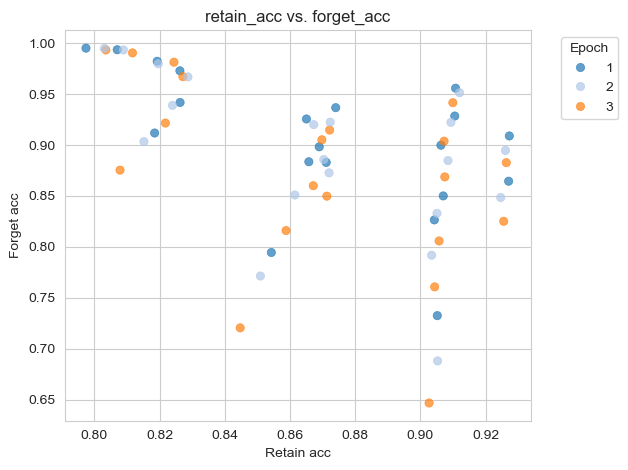

In [ ]:
import pandas as pd
import glob
import seaborn as sns
import re

def results_scatterplot(results_folder, x_metric, y_metric, subset = None):

    # gather subdirectories
    all_subdirs = []
    for root, dirs, files in os.walk(results_folder):
        for d in dirs:
            
            all_subdirs.append(os.path.join(root, d))
    if subset is not None:
        pattern = rf"_({'|'.join(map(str, subset))})$"
        all_subdirs = [d for d in all_subdirs if re.search(pattern, d)]
        

    # gather results
    all_results = []
    for subdir in all_subdirs:
        file_paths = glob.glob(os.path.join(subdir, "*.json"))
        df = pd.concat([pd.read_json(f, typ='series') for f in file_paths], axis=1).T
        all_results.append(df)
    final_df = pd.concat(all_results, axis=0)


    # plot
    plt.clf()
    sns.set_style("whitegrid")
    colors_list = list(plt.cm.tab20.colors)
    sns.scatterplot(
        data=final_df, 
        x=x_metric, 
        y=y_metric, 
        hue="epoch", 
        palette=colors_list,  # Use the list here
        alpha=0.7,
        edgecolor=None
    )
    # Formatting
    plt.title(f"{x_metric} vs. {y_metric}")
    plt.xlabel(x_metric.capitalize().replace("_", " "))
    plt.ylabel(y_metric.capitalize().replace("_", " "))
    plt.legend(title="Epoch", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()



results_scatterplot("results/seed_96/", x_metric = "retain_acc", y_metric = "forget_acc", subset=None)
# results_scatterplot("results/seed_42/", x_metric = "retain_acc", y_metric = "forget_acc", subset=[14, 16, 18, 20])